# Comparative Analysis of Turbo and LDPC Codes

## Abstract

**Turbo Codes** and **Low-Density Parity-Check (LDPC) Codes** are advanced **forward error correction (FEC)** techniques used in modern digital communication systems to improve reliability over noisy channels. This project performs a comparative analysis and explanation of Turbo and LDPC codes, focusing on **Bit Error Rate (BER)** and **decoding complexity**. Both codes are simulated over an **Additive White Gaussian Noise (AWGN)** channel with **Binary Phase Shift Keying (BPSK) modulation**. The study aims to represent the theory and math behind both code, their diffrences and similarities, on what conditions each code performs better than the other and when they are used.

## Introduction 

Reliable data transmission is a fundamental requirement in modern digital communication systems. During transmission over a communication channel, signals are inevitably affected by noise, interference, and other impairments that may introduce errors in the received data. In order to ensure accurate information recovery, communication systems employ error control techniques that can detect and correct errors during transmission. [3], [20]

**Forward Error Correction (FEC)** is a technique used in data transmission where the sender adds redundant data so the receiver can detect and correct a limited number of errors without needing retransmission. Because FEC does not require a prior connection or handshaking between sender and receiver, it allows efficient broadcasting of data to multiple destinations while reducing bandwidth and power usage. It is widely used in noisy communication channels such as wireless networks, video streaming, cellular systems, and in devices like modems and routers. When implementing FEC, a variety of error-correcting codes are used, some of them are Turbo and LDPC codes. [1], [21]

**Turbo** and **Low-Density Parity-Check (LDPC) codes** are used in modern digital communication systems to improve the reliability of data transmission over noisy channels. Both methods are capable of achieving performance close to the theoretical limit defined by the **Shannon capacity**. [2], [19]

**Turbo codes** use iterative decoding with parallel concatenated convolutional codes and interleavers, while **LDPC codes** rely on sparse parity-check matrices and iterative message-passing algorithms for efficient error correction. Due to their high performance, these codes are widely implemented in technologies such as cellular networks, satellite communications, Wi-Fi, and digital broadcasting. [2]

**The purpose of this study** is to perform a comparative analysis between both codes under controlled simulation conditions. They are evaluated using a digital communication model that includes **BPSK modulation** and an **AWGN channel**. The performance of the two coding schemes is analyzed based on **BER**, **decoding iterations**, and **computational complexity**.

**The main objective** of this work is to investigate the conditions under which coding technique performs more efficiently.

## Information and Coding Theories 

Before talking about these concepts it is important to have in my mind the diffrences about **error detection** and **error correction**.

**Error detection** identifies whether errors occurred during transmission by adding redundant information such as parity bits or checksums. It can detect errors but cannot correct them, so corrupted data usually requires retransmission. **Error correction** goes further by adding enough redundancy to both detect and fix errors without retransmission. [6]

The key difference is that **detection** only signals errors, while **correction** locates and fixes them. **Error correction** is more complex but ensures higher reliability, which is why modern systems rely on codes like **Turbo** and **LDPC** to approach theoretical limits.

Also, transmitted data can be affected by different types of errors caused by noise or interference in the channel. The most common types are **single-bit errors**, where only one bit in a codeword is flipped, and **burst errors**, where two or more consecutive bits are corrupted. **Single-bit errors** are easier to detect and correct with simple codes like **Hamming codes**, while **burst errors** require more sophisticated codes such as **Reed–Solomon** or **LDPC codes**. Understanding the type of errors in a channel is essential for designing effective error-correcting codes and ensuring reliable data transmission. [6]

### Information Theory

**Information theory**, introduced by **Claude Shannon**, provides the mathematical framework for analyzing the transmission of information over communication systems. It defines the theoretical limits of reliable communication and forms the basis for modern error-correcting codes such as Turbo and LDPC codes. A fundamental goal of information theory is to determine how efficiently information can be transmitted over a noisy channel while minimizing errors. [7], [13], [14]

The uncertainty of a **discrete information source** $X$ is measured by **entropy**, defined as:

$$
H(X) = -\sum_{i=1}^{n} p(x_i)\log_2 p(x_i)
$$

where $p(x_i)$ is the probability of symbol $x_i$. **Entropy** represents the average number of bits required to represent the output of the source. A source with higher randomness has higher entropy and therefore requires more bits to encode its information.

In communication systems it is also useful to define **joint entropy**, which measures the uncertainty of two random variables:

$$
H(X,Y) = -\sum_{x,y} p(x,y)\log_2 p(x,y)
$$

From this, the **conditional entropy** can be defined as the remaining uncertainty of $X$ given that $Y$ is known:

$$
H(X|Y) = H(X,Y) - H(Y)
$$

The statistical relationship between the transmitted signal $X$ and the received signal $Y$ is described by **mutual information**:

$$
I(X;Y) = H(X) - H(X|Y)
$$

Mutual information represents the amount of information about $X$ that can be obtained from observing $Y$. Maximizing this quantity is essential for designing efficient communication systems.

During transmission, the signal is affected by **noise**, commonly modeled as **Additive White Gaussian Noise (AWGN)**:

$$
Y = X + N
$$

where $X$ is the transmitted signal, $N$ is Gaussian noise with distribution

$$
N \sim \mathcal{N}(0,\sigma^2)
$$

and $Y$ is the received signal. Noise introduces uncertainty in the received symbols and leads to transmission errors.

The maximum achievable rate for reliable communication over a channel is called the **channel capacity**. For an AWGN channel it is given by the **Shannon–Hartley theorem**:

$$
C = B \log_2 \left(1 + \frac{S}{N}\right)
$$

- $C$ is the channel capacity in bits per second  
- $B$ is the bandwidth of the channel  
- $S$ is the average received signal power  
- $N$ is the average noise power  
- $S/N$ is the signal-to-noise ratio  

The ratio

$$
\text{SNR} = \frac{S}{N}
$$

is called the **Signal-to-Noise Ratio (SNR)** and determines the achievable data rate and reliability of the communication system. In practical systems, coding techniques such as **Turbo codes** and **LDPC codes** are used to approach this theoretical capacity limit while maintaining very low error probabilities.

### Coding Theory

**Coding theory** studies techniques for encoding information so that it can be transmitted reliably over noisy communication channels. It provides mathematical methods for detecting and correcting errors introduced during transmission. Coding theory is a fundamental component of modern digital communication systems and forms the basis for advanced error-correcting techniques such as Turbo and LDPC codes. [11]

In a communication system, an **error-correcting code** adds redundancy to the original information sequence in order to protect it from channel noise. A block of $k$ information bits is transformed into a **codeword** of length $n$ bits:

$$
\mathbf{c} = (c_1, c_2, \dots, c_n)
$$

where $\mathbf{c}$ belongs to a set of valid codewords called a **code**. The efficiency of a code is described by the **code rate**:

$$
R = \frac{k}{n}
$$

where  
- $k$ is the number of information bits  
- $n$ is the total number of transmitted bits.  

A higher code rate means less redundancy, while a lower code rate provides stronger error protection.

Many practical error-correcting codes belong to the class of **linear block codes**. In these codes, the encoding process can be represented using a **generator matrix** $G$:

$$
\mathbf{c} = \mathbf{u}G
$$

where  
- $\mathbf{u}$ is the vector of information bits of length $k$  
- $G$ is a $k \times n$ generator matrix  
- $\mathbf{c}$ is the encoded codeword.

Another important representation of linear block codes is the **parity-check matrix** $H$. Valid codewords must satisfy the condition:

$$
H \mathbf{c}^T = 0
$$

where $H$ is an $(n-k) \times n$ matrix. At the receiver, this property is used to detect errors through the **syndrome**:

$$
\mathbf{s} = H \mathbf{r}^T
$$

where $\mathbf{r}$ is the received vector and $\mathbf{s}$ is the syndrome. If $\mathbf{s} \neq 0$, an error has occurred during transmission.

Another fundamental concept in coding theory is the **Hamming distance**, which measures the number of differing bits between two codewords:

$$
H(\mathbf{x},\mathbf{y}) = \sum_{i=1}^{n} 1 (x_i \neq y_i)
$$

The **minimum distance** $d_{min}$ of a code determines its error detection and correction capability. A code with minimum distance $d_{min}$ can detect up to

$$
d_{min} - 1
$$

errors and can correct up to

$$
t = \left\lfloor \frac{d_{min}-1}{2} \right\rfloor
$$

errors.

In modern communication systems, advanced coding techniques use **iterative decoding algorithms** that exchange probabilistic information between decoding stages. **Turbo** and **LDPC codes** belong to this class of **capacity-approaching codes**, meaning they can achieve performance very close to the theoretical limits predicted by information theory.

## Turbo Code 

Turbo codes are a class of powerful forward error correction (FEC) codes introduced in the early 1990s. Their importance comes from the fact that they achieve performance remarkably close to the Shannon limit, especially on additive white Gaussian noise (AWGN) channels. The basic idea is to concatenate two simple constituent codes through an interleaver and then decode them iteratively using soft information exchange. [1], [2], [8]

A classical turbo encoder uses two **recursive systematic convolutional (RSC)** encoders connected in parallel. The first encoder processes the original information sequence, while the second processes an interleaved version of the same sequence. The transmitted codeword typically contains the systematic bits and the parity bits produced by both constituent encoders. [16], [17]

### Basic Principle of a Turbo Encoder

The generic parallel concatenated turbo encoder can be described as follows:

- the information sequence $\mathbf{u} = (u_1,u_2,\dots,u_N)$ is fed directly to the first RSC encoder,
- an interleaved version $\mathbf{u}_{\pi}$ is fed to the second RSC encoder,
- the output is composed of:
  - the **systematic sequence**,
  - the **first parity sequence**,
  - the **second parity sequence**.

Thus, before puncturing, the nominal code rate is usually

$$ R = \frac{1}{3}. $$

If some parity symbols are removed by puncturing, higher rates such as $1/2$ can be obtained. At the decoder, punctured symbols are commonly represented by zero-valued reliability inputs. [18], [23]

### Mathematical Model of the Encoder

Let the input information block be

$$
\mathbf{u} = (u_1,u_2,\dots,u_N), \qquad u_k \in \{0,1\}.
$$

After interleaving, the reordered sequence becomes

$$
\mathbf{u}_{\pi} = (u_{\pi(1)},u_{\pi(2)},\dots,u_{\pi(N)}),
$$

where $\pi(\cdot)$ is a permutation of the set $\{1,2,\dots,N\}$.

If the first constituent encoder produces parity sequence $\mathbf{p}^{(1)}$ and the second produces $\mathbf{p}^{(2)}$, then the transmitted turbo codeword is

$$
\mathbf{c} = \big(\mathbf{u}, \mathbf{p}^{(1)}, \mathbf{p}^{(2)}\big).
$$

For a non-punctured parallel concatenated turbo code, the total number of transmitted bits is approximately $3N$, hence

$$
R = \frac{N}{3N} = \frac{1}{3}.
$$

The interleaver is essential because it makes the two constituent encoders observe the same information bits in different orders, which greatly reduces the probability that both encoders generate low-weight parity patterns for the same input sequence. This effect is one of the main reasons for the excellent distance properties of turbo codes. [5], [24], [25]

### Why the Interleaver is Critical

The interleaver does not change the set of information bits; it only changes their order:

$$
u_k \longrightarrow u_{\pi(k)}.
$$

This reordering decorrelates the error events seen by the two constituent encoders. In other words, if one encoder happens to produce a low-weight output for a certain input pattern, the second encoder is unlikely to produce a low-weight output for the interleaved version of the same pattern. This effect is often described as **interleaver gain**. A good turbo code therefore has a relatively thin low-weight distance spectrum compared with simpler constructions.

### Turbo Decoding and Iterative Processing

Turbo decoding is based on **iterative soft-input soft-output (SISO)** processing. Instead of making a hard decision after one pass, the decoder refines its estimates by exchanging probabilistic information between two constituent decoders. [10]

For each information bit $X_i$, the decoder computes the log-likelihood ratio (LLR)

$$
L(X_i) = \ln \frac{P(X_i=1 \mid \mathbf{Y})}{P(X_i=0 \mid \mathbf{Y})},
$$

where $\mathbf{Y}$ denotes the received observations. A hard decision is then obtained from the sign of the LLR:

$$
\hat{X}_i =
\begin{cases}
1, & L(X_i) > 0,\\[4pt]
0, & L(X_i) < 0.
\end{cases}
$$

This LLR-based formulation is central to turbo decoding because it allows reliability information, not just binary decisions, to be exchanged between iterations. [4], [12]

### Extrinsic Information

A turbo decoder must avoid feeding back the same information repeatedly in an unstable way. For that reason, each constituent decoder passes only the information that is **new** relative to the other decoder. This quantity is called **extrinsic information**.

If a SISO decoder produces an a posteriori LLR $L^{\text{post}}(X_i)$, and the systematic channel contribution is $L^{\text{sys}}(X_i)$, then the extrinsic part can be written conceptually as

$$
L^{\text{ext}}(X_i)
= L^{\text{post}}(X_i) - L^{\text{sys}}(X_i) - L^{\text{apr}}(X_i),
$$

where $L^{\text{apr}}(X_i)$ is the a priori information supplied by the other decoder from the previous half-iteration.

The second decoder receives an interleaved version of this extrinsic information:

$$
L^{\text{apr}}_2(X_{\pi(i)}) = \Pi\left\{L^{\text{ext}}_1(X_i)\right\},
$$

and similarly the first decoder later receives the deinterleaved output from the second decoder:

$$
L^{\text{apr}}_1(X_i) = \Pi^{-1}\left\{L^{\text{ext}}_2(X_{\pi(i)})\right\}.
$$

This exchange of extrinsic information is the essence of the turbo principle. [1]

### MAP / BCJR Decoding

The constituent SISO decoders in turbo codes are commonly implemented using the **MAP** algorithm or one of its logarithmic approximations such as **Log-MAP** or **Max-Log-MAP**. The BCJR algorithm is the classical MAP-based method used for symbol-by-symbol a posteriori probability estimation on a trellis. [22]

Unlike the Viterbi algorithm, which is aimed at selecting the most likely sequence, MAP/BCJR decoding estimates the probability of each individual bit. This makes it especially suitable for iterative decoding because it naturally produces soft outputs. BCJR involves both forward and backward recursions over the trellis, which gives better bit-wise reliability information at the cost of greater complexity. [24], [25]

### Iterative Gain

Turbo decoder performance improves as the number of iterations increases, especially in the first few iterations. However, the improvement is not linear; after several iterations, the gain becomes progressively smaller. This is why practical systems usually use a limited number of iterations rather than decoding indefinitely.

In abstract form, the iterative process can be written as

$$
L^{(m+1)}_{\text{apr},1} = \Pi^{-1}\!\left(f_2\!\left(\Pi\!\left(f_1(L^{(m)}_{\text{apr},1})\right)\right)\right),
$$

- $L^{(m)}_{\text{apr},1}$ - a priori log-likelihood ratios (LLRs) for the first component decoder at iteration $m$ LLRs are used in soft-decision decoding to represent the probability that a bit is 0 or 1;
- $f_1$ and $f_2$ - Functions representing the decoding operations of the two component decoders (usually convolutional decoders). They take the LLRs and compute updated probabilities for each bit;
- $\Pi$ - An interleaver, which permutes (reorders) the bits of the input sequence to spread errors and reduce correlation between bits;
- $\Pi^{-1}$ - The deinterleaver, which reverses the interleaving operation to restore the original bit order;
- $L^{(m+1)}_{\text{apr},1}$ - The updated a priori LLRs for the next iteration $m + 1$

This repeated refinement is what allows turbo codes to approach near-capacity performance with relatively simple constituent encoders. [12], [23]

### Advantages and Limitations of Turbo Codes

The main advantages of turbo codes are:

- **Near-Shannon-limit performance** on AWGN channels.
- **Excellent BER performance** due to iterative soft decoding.
- **Strong coding gain** even though the constituent encoders are relatively simple.
- **Flexibility** through interleaver design, puncturing, and different decoding algorithms.

Because of these properties, turbo codes were adopted in important communication systems and standards, including third-generation cellular systems and other high-reliability communication applications.

Despite their strong error-correcting capability, turbo codes also have practical disadvantages:

- iterative decoding increases **latency**,
- MAP-based decoding has relatively high **computational complexity**,
- decoder implementations require significant **memory** for trellis metrics,
- performance depends strongly on **interleaver design** and stopping criteria.

These tradeoffs explain why turbo codes are highly effective but computationally heavier than many classical block or convolutional codes. [9], [24]

### Performances

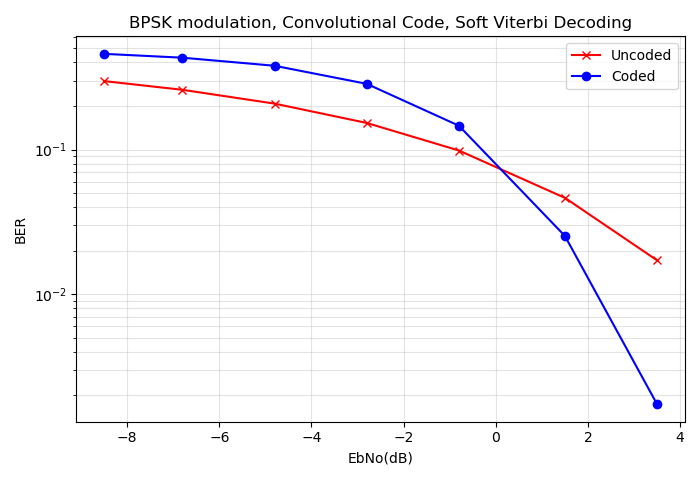

The **first graph** compares uncoded BPSK with convolutionally coded BPSK using soft Viterbi decoding, so it works as the baseline that shows what a classical coded system can already achieve. The coded curve drops much faster than the uncoded one as $E_b/N_0$ increases, which reflects the coding gain obtained by adding redundancy and then decoding with a trellis-based algorithm that uses soft channel information rather than hard binary decisions. In practical terms, this means the receiver can correct many more errors once the signal quality becomes moderately good. For a turbo-code article, this figure is useful because it establishes the performance level of conventional convolutional coding before introducing the extra gains made possible by interleaving and iterative decoding.

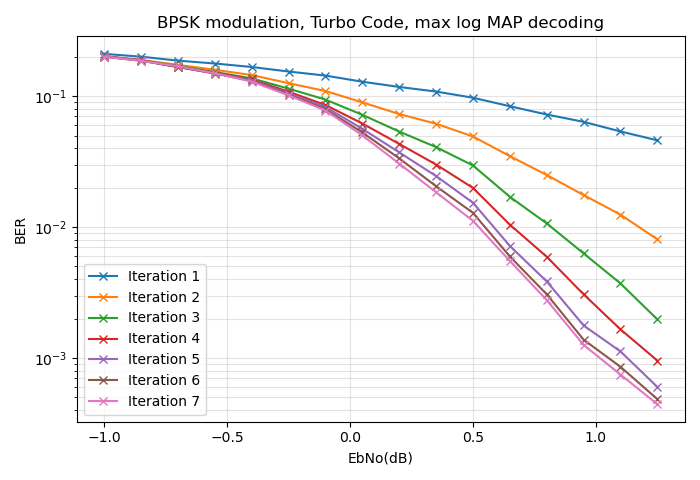

The **second graph** is the main turbo-code performance plot, because it shows BER for a turbo-coded BPSK system under Max-Log-MAP decoding across iterations 1 through 7. A turbo code is formed by the parallel concatenation of two constituent encoders separated by an interleaver, and its strength comes from iterative soft-input soft-output decoding rather than a single decoding pass. That behavior is visible here: iteration 1 has the highest BER, while each additional iteration pushes the curve downward, meaning the decoder is refining its bit estimates by exchanging extrinsic information. The fact that the last few curves get closer together is also important, because it shows diminishing returns: most of the turbo gain is achieved in the first several iterations, and later iterations mainly provide smaller refinements.

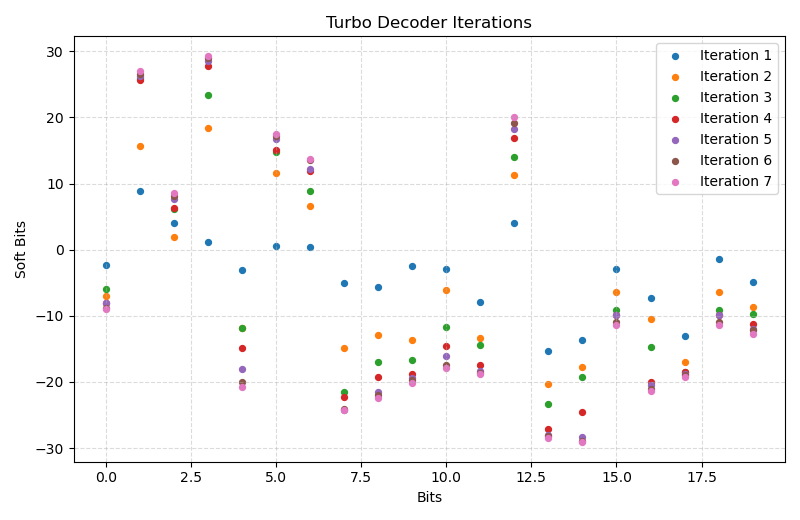

The **third graph** explains why the second graph improves: it shows the evolution of the decoder’s soft values for individual bits across iterations. In turbo decoding, the receiver does not immediately commit to a hard 0 or 1 for each bit; instead, it updates a reliability value, often expressed through an LLR-like quantity, and passes only the newly generated extrinsic part to the other constituent decoder. In the plot, many points move farther away from zero as the iterations increase, which means the decoder is becoming more confident about those bit decisions. So this graph is not mainly about BER itself, but about convergence: it visualizes the internal mechanism by which iterative decoding stabilizes uncertain bits and turns them into increasingly reliable final decisions.

## Low-Density Parity-Check Codes

**LDPC codes** are powerful linear block codes defined by a **sparse parity-check matrix**. Their main appeal is that they combine excellent error-correction performance with decoding algorithms that are practical for long block lengths. Because of these properties, LDPC codes are among the most important modern forward error correction schemes and are widely associated with near-Shannon-limit operation. [2]

An LDPC code is usually described not by a dense generator structure, but by a sparse parity-check matrix $H$. The sparsity of $H$ is what makes iterative decoding efficient, since decoding can be interpreted as local message exchange on a graph rather than global exhaustive search. [8]

### Basic Definition of an LDPC Code

An LDPC code is a binary linear block code whose valid codewords satisfy

$$
\mathbf{c} H^{T} = \mathbf{0},
$$

where $\mathbf{c}$ is a length-$n$ codeword and $H$ is an $(n-k)\times n$ sparse parity-check matrix. The term *low-density* means that the number of ones in $H$ is very small compared with the total number of matrix entries.

If the code has parameters $(n,k)$, then the code rate is

$$
R = \frac{k}{n}.
$$

As with other block codes, a lower rate means more redundancy and usually better protection, while a higher rate means less redundancy and greater spectral efficiency. [12]

### Sparse Parity-Check Matrix

The parity-check matrix $H$ is the central object in LDPC coding. Each row corresponds to one parity-check equation, and each column corresponds to one codeword bit. A codeword belongs to the LDPC code if it satisfies all parity constraints simultaneously.

For a sparse matrix, the number of ones per row and per column is small. In a **regular LDPC code**, every column has the same weight $w_c$ and every row has the same weight $w_r$. In an **irregular LDPC code**, these weights vary, and carefully optimized irregular degree distributions can bring performance very close to channel capacity. [2], [19]

### Tanner Graph Representation

LDPC codes are naturally represented by a **Tanner graph**, which is a bipartite graph composed of:

- **variable nodes**, representing code bits,
- **check nodes**, representing parity constraints.

An edge connects variable node $v_j$ to check node $c_i$ if and only if the entry $h_{ij}=1$ in the parity-check matrix. This graph representation is fundamental because LDPC decoding is performed by passing messages along these edges.

If the Tanner graph were cycle-free, message-passing decoding would be optimal. In practice LDPC graphs do contain cycles, but for long well-designed codes they behave locally almost like trees, which is one of the reasons iterative decoding works so well.

### Encoding Principle

A codeword $\mathbf{c}$ must satisfy the parity-check condition

$$
\mathbf{c}H^{T} = \mathbf{0}.
$$

One classical way to encode is to derive a generator matrix $G$ from the parity-check matrix and compute

$$
\mathbf{c} = \mathbf{m}G,
$$

where $\mathbf{m}$ is the $k$-bit information vector. However, while $H$ is sparse, the corresponding generator matrix $G$ is often not sparse, which can make direct encoding computationally expensive.

For this reason, practical LDPC systems often use structured constructions of $H$ that simplify encoding while preserving the advantages of sparse iterative decoding. [2]

### Iterative Message-Passing Decoding

The most important feature of LDPC codes is their decoding method: **iterative message passing**, also called **belief propagation** or the **sum-product algorithm**. The decoder exchanges reliability information between variable nodes and check nodes repeatedly until the parity-check constraints are satisfied or a maximum number of iterations is reached.  

This approach is fundamentally different from algebraic block decoding. Instead of making a single global hard decision, the LDPC decoder gradually refines the probability estimates of each bit. This local iterative processing is exactly what makes LDPC codes both powerful and scalable to long code lengths. [2]

### Log-Likelihood Ratio Formulation

In soft-decision decoding, each received bit is represented by a log-likelihood ratio (LLR),

$$
L(x_i) = \ln \frac{P(x_i=0 \mid y_i)}{P(x_i=1 \mid y_i)}.
$$

The sign of $L(x_i)$ indicates the estimated bit value, while the magnitude indicates confidence. Large positive or negative magnitude means high reliability, while values close to zero indicate uncertainty.

During message passing, variable nodes and check nodes exchange updated LLR-like messages. After several iterations, the decoder forms an a posteriori estimate for each bit and checks whether all parity equations are satisfied. [3], [25]

### Variable-Node and Check-Node Updates

At a high level, variable nodes combine the channel information with incoming messages from neighboring check nodes. A simplified variable-node update can be written as

$$
L_{v \to c}^{(t)} = L_{\text{ch}} + \sum_{c' \in \mathcal{N}(v)\setminus c} L_{c' \to v}^{(t-1)},
$$

- $L_{v \to c}^{(t)}$ – message (log-likelihood ratio, **LLR**) sent from **variable node** $v$ to **check node** $c$ at iteration $t$.

- $L_{\text{ch}}$ – **channel log-likelihood ratio**, representing the reliability information obtained from the received signal.

- $\mathcal{N}(v)$ – the **set of check nodes connected** to the variable node $v$ in the Tanner graph.

- $\mathcal{N}(v)\setminus c$ – all neighboring check nodes of $v$ **except** node $c$.

- $L_{c' \to v}^{(t-1)}$ – message (LLR) sent from **check node** $c'$ to **variable node** $v$ during the **previous iteration** $(t-1)$.

The check-node update enforces parity consistency. In exact sum-product decoding, the outgoing check-node message depends on the signs and magnitudes of all incoming variable-node messages except the destination edge. In practice this is often implemented either exactly or through approximations such as min-sum for lower complexity. The overall decoding process is therefore an iterative exchange of extrinsic information across the Tanner graph. [19]

### Bit-Flipping and Sum-Product Decoding

LDPC decoding can be divided into two broad classes:

1. **Hard-decision decoding**, such as bit-flipping algorithms,
2. **Soft-decision decoding**, such as sum-product / belief propagation.

Bit-flipping is simpler but less powerful, since it works only with binary decisions and local parity violations. Sum-product uses probabilistic information and usually achieves much better performance. This is why soft iterative decoding is the dominant practical choice in modern LDPC systems. [8]

### Advantages and Disadvantages

The main advantages of LDPC codes are:

- **Near-capacity performance** with iterative decoding,
- **Scalability to long block lengths**,
- **Efficient message-passing implementation** due to sparse graphs,
- **Strong soft-decision performance** on practical channels,
- **Flexibility** through regular and irregular constructions.

Despite their excellent performance, LDPC codes also have practical limitations:

- performance depends strongly on graph design,
- short cycles and harmful graph structures can degrade decoding,
- iterative decoding introduces latency,
- encoding can be more difficult than decoding if the structure is not chosen carefully.

Another important issue is that iterative decoders are local rather than global. This local nature makes them efficient, but it also means that they can converge to incorrect configurations, sometimes described in the literature through pseudo-codeword effects and related graph phenomena. [2]

### Performances

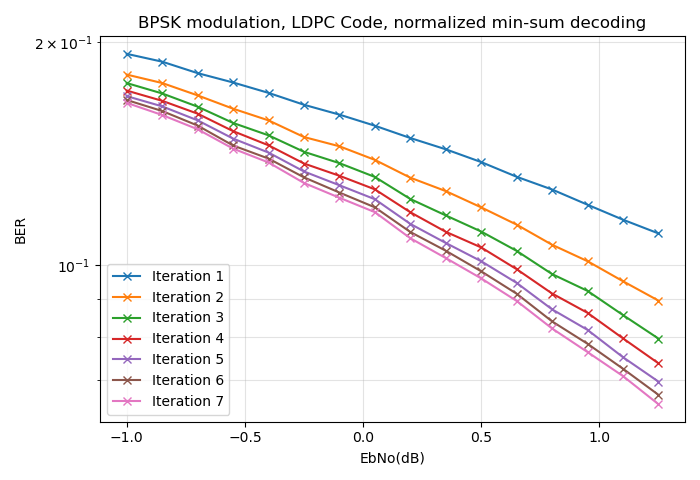

The **first graph** shows the **BER performance of an LDPC-coded BPSK system** using normalized min-sum decoding over multiple iterations. Its main message is that LDPC decoding, like turbo decoding, improves through iteration: the curve for iteration 1 has the highest BER, and each additional iteration shifts the BER downward. This happens because the LDPC decoder repeatedly exchanges reliability messages between variable nodes and check nodes in the Tanner graph, so the estimate of each bit becomes progressively more accurate. The fact that the separation between later curves becomes smaller is also important, because it indicates diminishing returns: the first few iterations provide the largest gain, while later iterations mostly refine the result. In an article, this graph is the main LDPC performance figure because it directly shows how iterative message-passing decoding improves error-rate performance as $E_b/N_0$ increases.

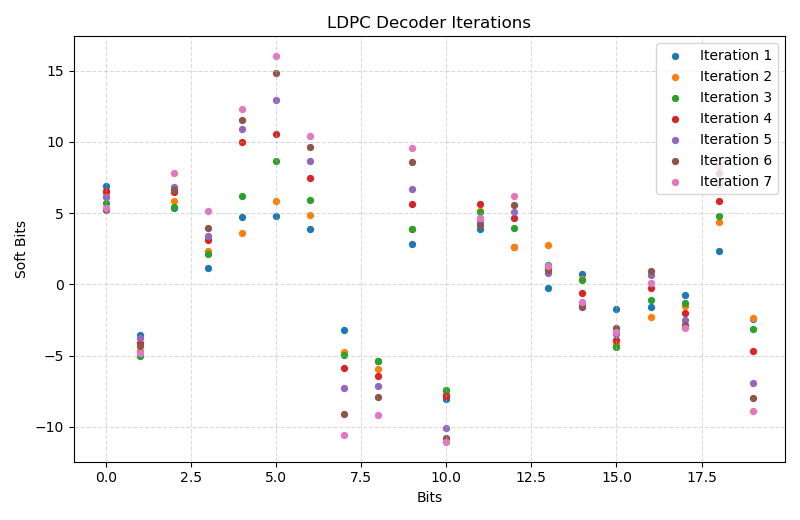

The **second graph** explains the **internal behavior behind that BER improvement** by showing the evolution of soft bit values across LDPC decoder iterations. These soft values represent the decoder’s confidence about each bit, typically in an LLR-like form, where the sign suggests the estimated bit value and the magnitude indicates reliability. As the iteration number increases, many points move farther from zero, meaning the decoder is becoming more certain about those bits after repeated message exchange across the parity-check graph. Bits that remain close to zero are the most ambiguous and are more likely to contribute to decoding errors, while bits with large positive or negative values are effectively resolved with high confidence. This figure is especially useful for explanation, because it shows that LDPC performance improves not by a single hard decision, but by gradual convergence of soft information during iterative decoding.

## Comparison

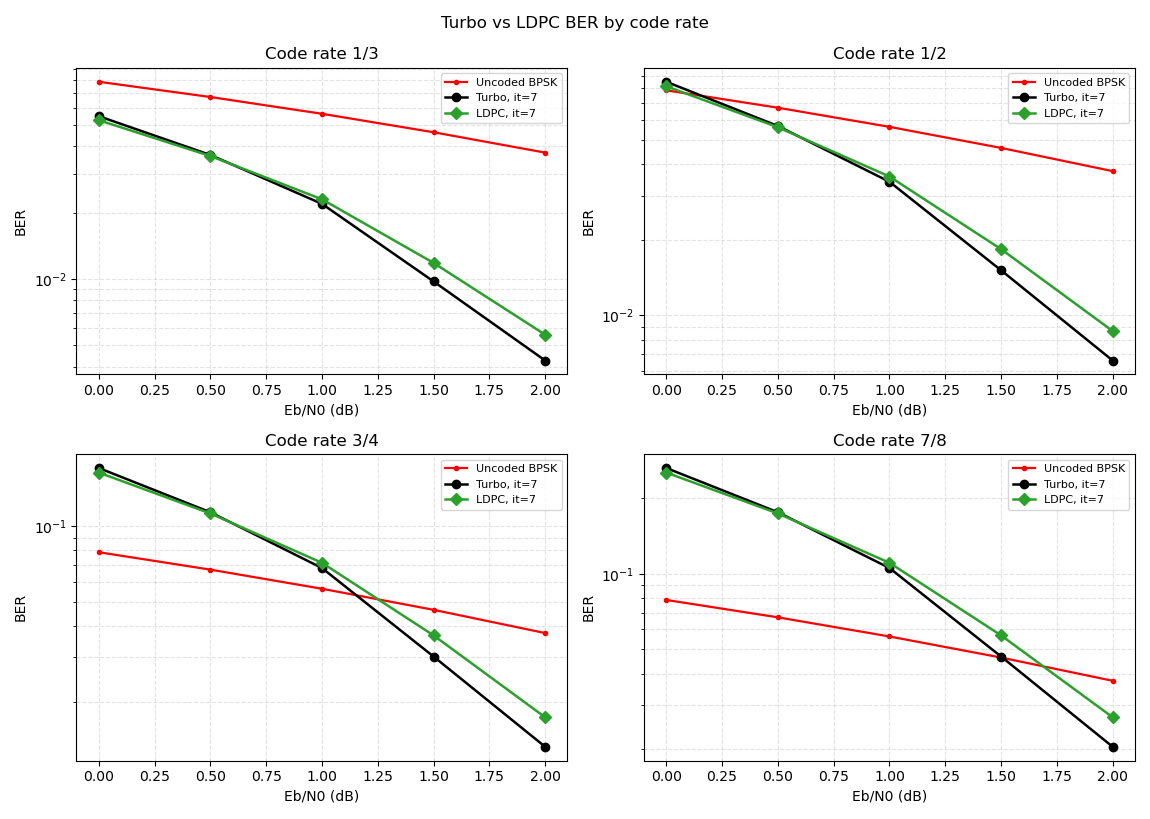

The **first figure** shows the direct **BER comparison between turbo and LDPC codes** as the code rate changes, so it is the main performance result of the comparison. At the lowest rate, $R=\frac{1}{3}$, both schemes achieve strong error protection because a large amount of redundancy is available, and their BER curves fall well below the uncoded BPSK baseline. As the rate increases to $\frac{1}{2}$, $\frac{3}{4}$, and $\frac{7}{8}$, both coded curves shift upward, which means performance degrades because less parity information is transmitted, but the figure also shows an important distinction: turbo and LDPC remain much better than uncoded transmission even when redundancy is reduced. In these plotted results, turbo is consistently slightly lower than LDPC at the highest $\frac{E_b}{N_0}$ point, especially for the larger rates, which suggests that in this setup turbo decoding extracts a bit more coding gain in the high-SNR region. The practical interpretation is that both codes are highly competitive, but turbo appears to have a small BER advantage in the waterfall region of these results, whereas LDPC stays close enough that the final engineering choice would likely depend on implementation constraints rather than raw BER alone.

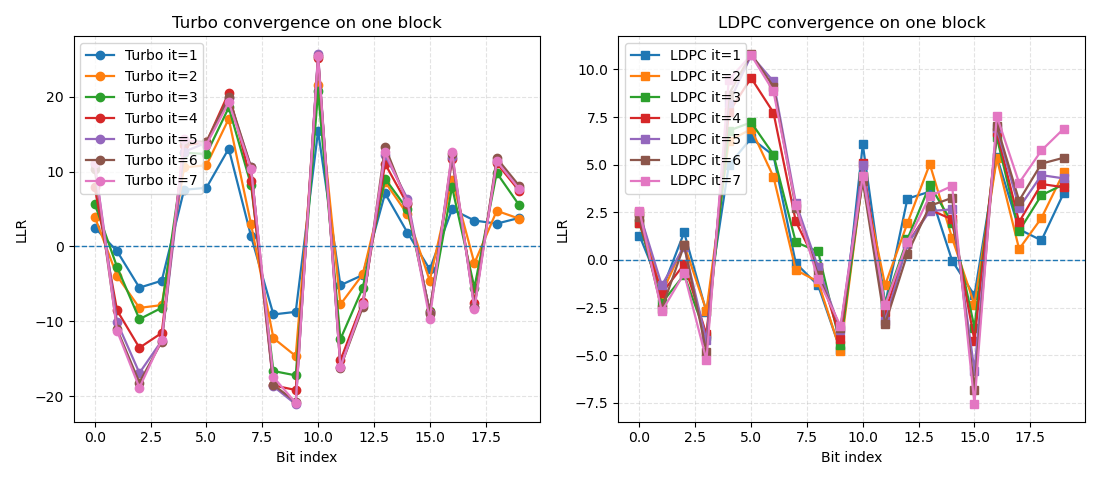

The **second plot** compares the **convergence behavior of turbo and LDPC decoding** by showing how the soft decision values evolve over multiple iterations. This is important because it reveals the difference in how the two decoders improve performance. In the turbo subplot, the soft values move more strongly away from zero across iterations, which reflects the exchange of extrinsic information between the two constituent decoders; as the iterations proceed, many bits become much more reliable. In the LDPC subplot, the same convergence principle appears, but through message passing on the Tanner graph between variable nodes and check nodes. The LDPC trajectories are often more moderate and distributed, while the turbo curves show stronger outward movement for some bits, indicating a more pronounced iterative refinement on this example block. For the article, this figure is useful because it does not only show that both decoders improve with iteration, but also highlights that turbo and LDPC reach that improvement through different iterative mechanisms.

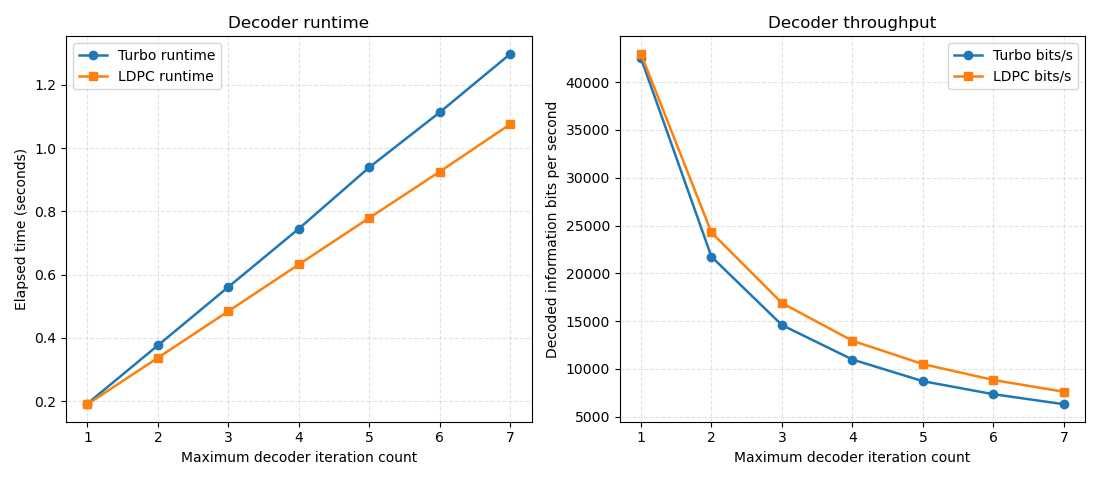

The **third plot compares turbo and LDPC in terms of runtime and throughput**, which is where the practical distinction between the two codes becomes especially clear. The runtime panel shows that both decoders require more time as the maximum number of iterations increases, which is expected because each extra iteration adds another full round of decoding. However, the turbo decoder consistently takes more time than the LDPC decoder for the same iteration count, which suggests a heavier computational burden, likely due to the repeated trellis-based Max-Log-MAP processing in turbo decoding. The throughput panel shows the inverse relationship: as iteration count grows, the number of decoded information bits per second decreases for both schemes, but LDPC remains slightly ahead. This makes the plot very important in a comparison study, because it shows the tradeoff between error-correction strength and implementation cost: turbo decoding may offer slightly better BER in some regions, but LDPC decoding can be more attractive when lower latency and higher throughput are required.

## Conclusion and Future Work

**This work shows** that turbo and LDPC codes are both highly effective modern channel-coding techniques, but they emphasize different strengths. From the BER comparison, turbo decoding achieves a slight performance advantage in the examined high-SNR region, especially at the stronger iterative settings, which suggests that in this setup it extracts somewhat more coding gain from the available redundancy. LDPC, however, stays very close in BER across all tested code rates, which confirms that it is a highly competitive alternative rather than a clearly weaker one. The convergence plots further support this interpretation: turbo decoding appears to push bit reliabilities more aggressively away from zero through iterative exchange of extrinsic information, while LDPC improves reliability through steadier Tanner-graph message passing. When the computational side is included, the comparison becomes clearer: LDPC provides lower runtime and higher throughput for the same iteration budget, while turbo offers slightly stronger error-rate performance. Therefore, the overall conclusion is that turbo codes are preferable when maximum BER improvement is the main objective, whereas LDPC codes are preferable when decoding efficiency, scalability, and throughput are more important.

**Future work** is to extend the comparison beyond the current fast study and perform a full-scale simulation campaign with larger block lengths, more $E_b/N_0$ points, and more frames so that the BER curves are fully measured rather than partly illustrative. It would also be valuable to compare the codes under different decoding algorithms, for example Log-MAP versus Max-Log-MAP for turbo codes and sum-product versus normalized min-sum for LDPC, in order to separate algorithmic effects from code-structure effects. Another important direction is to study the impact of interleaver design in turbo codes and graph construction / degree distribution in LDPC codes, since these structural choices strongly affect both convergence and BER performance. Finally, the comparison could be extended to more practical criteria such as latency, memory usage, hardware complexity, and energy efficiency, because in real communication systems the best coding scheme is rarely chosen only from BER curves; it is chosen from the balance between reliability and implementation cost.

## References

[1] Anritsu. FEC Overview White Paper. [Online]. Available: https://dl.cdn-anritsu.com/en-us/test-measurement/files/Technical-Notes/White-Paper/MP1591A_FEC_ER1100.pdf

[2] Biglieri, E. LDPC and Turbo Codes. In Coding for the Wireless Channel. [Online]. Available: https://www.mlsptlab-unicampania.it/images/palmieri/Information_Theory_and_Coding_/Ch9_LDPC_and_TurboCodes_Biglieri_CodingForThe_WirelessChannel.pdf

[3] Couvreur, A. Lecture Notes. [Online]. Available: https://www.lix.polytechnique.fr/~alain.couvreur/doc_ens/lecture_notes.pdf

[4] DaulPavid. pyturbo. GitHub repository. [Online]. Available: https://github.com/DaulPavid/pyturbo

[5] DaulPavid. (2018). Turbo Codes. [Online]. Available: https://daulpav.id/2018/10/16/turbo-codes.html

[6] Dronacharya Group of Institutions. Digital Electronics Question Bank. [Online]. Available: https://ggn.dronacharya.info/csedept/Downloads/QuestionBank/Odd/III%20sem/Section-A/digital-electronics_2.pdf

[7] GeeksforGeeks. Shannon Capacity. [Online]. Available: https://www.geeksforgeeks.org/electronics-engineering/shannon-capacity/#what-is-shannons-channel-capacity

[8] Ikeda, S. (2005). Information Geometry of Turbo and LDPC Codes. In Proc. ICASSP 2005. [Online]. Available: https://www.ism.ac.jp/~shiro/papers/conferences/icassp2005.pdf

[9] IEEE 802.16. PHY Contribution Document. [Online]. Available: https://www.ieee802.org/16/tg1/phy/contrib/802161pc-00_35.pdf

[10] Janati, H. pyldpc. GitHub repository. [Online]. Available: https://github.com/hichamjanati/pyldpc

[11] Lindell, Y. Introduction to Coding Theory: Lecture Notes. [Online]. Available: https://yehudalindell.com/wp-content/uploads/2023/06/coding_theory-lecture-notes.pdf

[12] MacKay, D. J. C. (2003). Information Theory, Inference, and Learning Algorithms. Cambridge University Press. [Online]. Available: https://www.inference.org.uk/itprnn/book.pdf

[13] Mathar, R. Lecture Notes on Information Theory. RWTH Aachen University. [Online]. Available: https://www.ti.rwth-aachen.de/teaching/InformationTheory/ws1819/data/InformationTheory.pdf

[14] Montanari, A. Introduction to Information Theory. [Online]. Available: https://web.stanford.edu/~montanar/RESEARCH/BOOK/partA.pdf

[15] Mustansiriyah University. Lecture Notes. [Online]. Available: https://www.uomustansiriyah.edu.iq/media/lectures/12/12_2017_03_24!09_36_55_PM.pdf

[16] NASA Technical Reports Server. Coding-Related Report. [Online]. Available: https://ntrs.nasa.gov/api/citations/19970009858/downloads/19970009858.pdf

[17] OAJI. Turbo-Code-Related Article. [Online]. Available: https://oaji.net/articles/2016/786-1462014300.pdf

[18] Plex1. turpy. GitHub repository. [Online]. Available: https://github.com/plex1/turpy

[19] Richardson, T., & Urbanke, R. (2008). Modern Coding Theory. Cambridge University Press. [Online]. Available: https://www.karlin.mff.cuni.cz/~holub/soubory/ModernCodingTheory.pdf

[20] SageMath Documentation. Coding Theory. [Online]. Available: https://doc.sagemath.org/pdf/en/reference/coding/coding.pdf

[21] TechTarget. Forward Error Correction (FEC). [Online]. Available: https://www.techtarget.com/searchmobilecomputing/definition/forward-error-correction

[22] Technical University of Sofia. ICEST 2004 Paper. [Online]. Available: http://rcvt.tu-sofia.bg/ICEST2004_1_78.pdf

[23] University of Southampton. AWCNS Lecture 16. [Online]. Available: https://www.southampton.ac.uk/~sqc/ELEC6214/AWCNS-L16.pdf

[24] Valenti, M. C., & Sun, J. (2004). “Turbo codes.” In Handbook of RF and Wireless Technologies, pp. 375–399. [Online]. Available: https://community.wvu.edu/~mcvalenti/documents/DOWLA-CH12.pdf  ￼

[25] Weitzen, J., & Sklar, B. Turbo Codes Class Notes / Fundamentals of Turbo Codes. [Online]. Available: https://faculty.uml.edu/jweitzen/16.548/ClassNotes/art_sklar3_turbocodes.pdf  ￼
